## Project Objective
Build and train a Neural Network to classify handwritten digits (0–9)
using the MNIST dataset and analyse model performance through
hyperparameter tuning and visualization.

### 1. Import Required Libraries

In [22]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Input
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical  # for one-hot-encoding
import matplotlib.pyplot as plt
import numpy as np

### 2. Load the MNIST Dataset
The MNIST dataset contains 70,000 grayscale images of handwritten digits.
Each image has dimensions of 28 × 28 pixels.

In [3]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

### 3. View Dataset

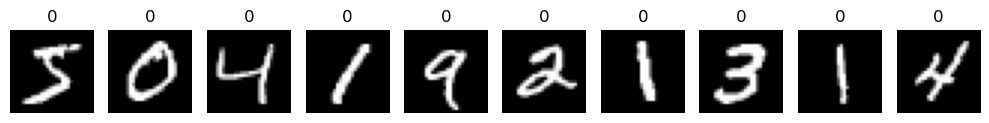

In [4]:
plt.figure(figsize = (10,2))
for i in range(10):
    plt.subplot(1, 10, i+1)
    plt.imshow(x_train[i], cmap= "gray")
    plt.axis("off")
    plt.title(str(np.argmax(y_train[i])))
plt.tight_layout()
plt.savefig("visualizing-first-10.png")
plt.show()

### 4. Data Preprocessing
Normalize Pixel Values. Pixel values are scaled from [0,255] to [0,1] to improve training stability.

In [5]:
x_train = x_train/255.0
x_test = x_test/255.0

In [6]:
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

### 5. Neural Network Architecture

In [7]:
model = Sequential([
    Input(shape=(28,28)),
    Flatten(),
    Dense(256, activation = "relu"),
    Dense(128, activation='relu'),
    Dense(10, activation = "softmax")
])

### 6. Compile the Model
Configuring optimizer, loss function, and evaluation metric.

In [8]:
model.compile(
    optimizer = "adam",
    loss = "categorical_crossentropy",
    metrics = ['accuracy']
)

### 7. Train the Model
Training neural network.

In [9]:
 model.fit(x_train, y_train, epochs = 10, batch_size = 32)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - accuracy: 0.9389 - loss: 0.2034
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 6ms/step - accuracy: 0.9732 - loss: 0.0855
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 6ms/step - accuracy: 0.9812 - loss: 0.0582
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 6ms/step - accuracy: 0.9855 - loss: 0.0445
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 6ms/step - accuracy: 0.9891 - loss: 0.0346
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 23s 7ms/step - accuracy: 0.9905 - loss: 0.0289
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 6ms/step - accuracy: 0.9923 - loss: 0.0236
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 23s 7ms/step - accuracy: 0.9938 - loss: 0.0189
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 7ms/step - accuracy: 0.9942 - loss: 0.0178
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 6ms/step - accuracy: 0.9941 - loss: 0.0167


### 8. Evaluate Model Performance
Measuring accuracy on unseen test data.

In [10]:
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f"The test accuracy is {test_acc}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9765 - loss: 0.1149        
The test accuracy is 0.9764999747276306


In [11]:
history = model.fit(
    x_train,
    y_train,
    epochs=10,
    validation_split=0.2
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.9947 - loss: 0.0155 - val_accuracy: 0.9953 - val_loss: 0.0142
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 22s 9ms/step - accuracy: 0.9967 - loss: 0.0102 - val_accuracy: 0.9945 - val_loss: 0.0167
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 17s 6ms/step - accuracy: 0.9958 - loss: 0.0131 - val_accuracy: 0.9934 - val_loss: 0.0212
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.9963 - loss: 0.0123 - val_accuracy: 0.9925 - val_loss: 0.0231
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 17s 7ms/step - accuracy: 0.9962 - loss: 0.0121 - val_accuracy: 0.9918 - val_loss: 0.0314
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.9967 - loss: 0.0099 - val_accuracy: 0.9934 - val_loss: 0.0238
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 22s 9ms/step - accuracy: 0.9969 - loss: 0.0108 - val_accuracy: 0.9918 - val_loss: 0.0347
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 18s 8ms/step - accuracy: 0.9965 - loss: 0

### 9. Predicting single digit

In [14]:
sample = x_test[0]

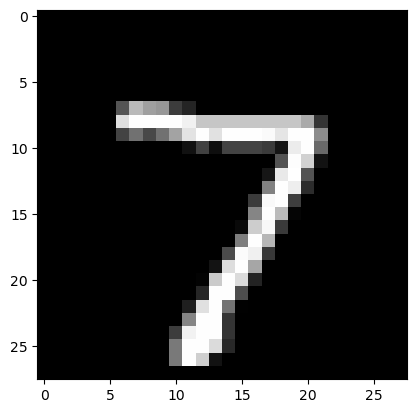

In [15]:
plt.imshow(sample, cmap="gray")
plt.show()

In [16]:
prediction = model.predict(sample.reshape(1,28,28))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step


In [17]:
predicted_digit = np.argmax(prediction)
print("Predicted Digit:", predicted_digit)

Predicted Digit: 7


In [18]:
print("Actual Digit:", np.argmax(y_test[0]))

Actual Digit: 7


### 10. Predicting digits in given range

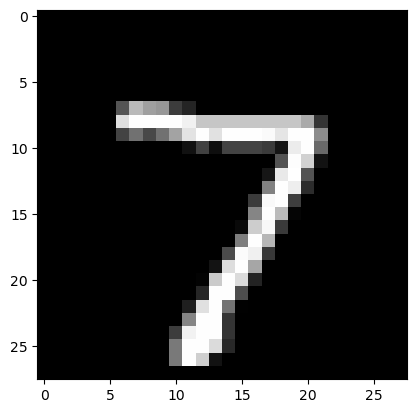

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
Prediction: 7
Actual: 7


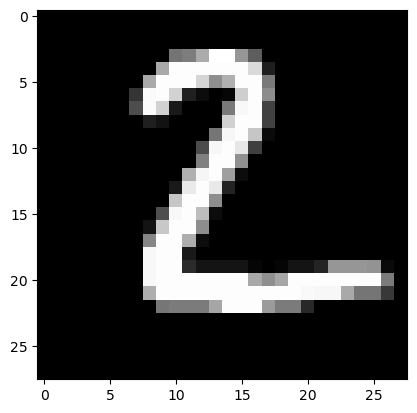

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
Prediction: 2
Actual: 2


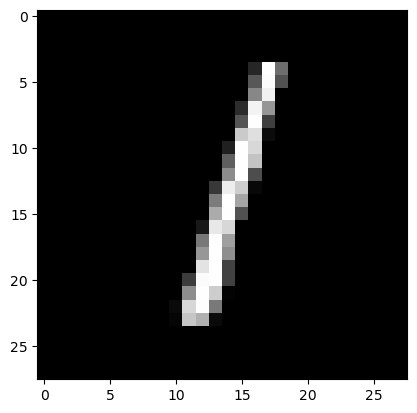

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Prediction: 1
Actual: 1


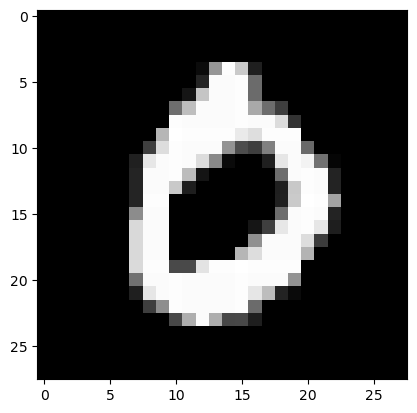

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Prediction: 0
Actual: 0


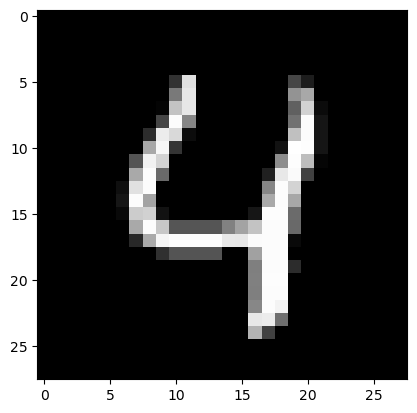

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
Prediction: 4
Actual: 4


In [19]:
for i in range(5):
    plt.imshow(x_test[i], cmap='gray')
    plt.show()

    pred = model.predict(x_test[i].reshape(1,28,28))

    print("Prediction:", np.argmax(pred))
    print("Actual:", np.argmax(y_test[i]))

### 11. Hyperparameter Experiments

| Experiment   | Changes               | Accuracy                |
| ------------ | --------------------- | ----------------------- |
| Base     | Dense(128), 5 Epochs  | 97.78%                  |
| Experiment 1 | Dense(256), 10 Epochs | 97.68%                  |
| Experiment 2 | Dense(256)+Dense(128) | 97.85%                  |
| Experiment 3 | Added Dropout(0.2)    | Improved Generalization |


### Observations:

- Increasing neurons alone did not improve performance.
- Adding another hidden layer slightly improved accuracy.
- Longer training caused overfitting.
- Dropout reduced overfitting and improved generalization.

### 12. Visualizing Accuracy and Loss curves

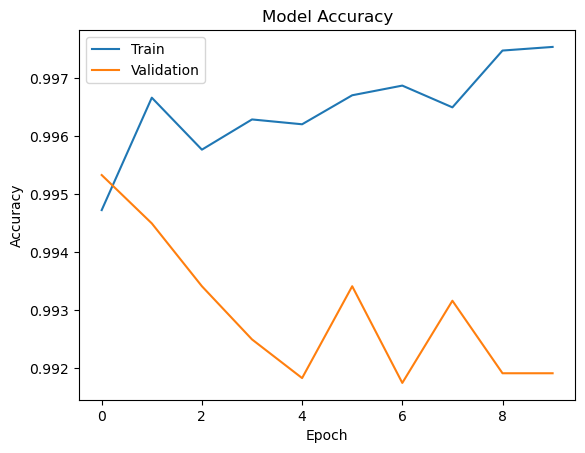

In [20]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")
plt.ylabel("Accuracy")
plt.xlabel("Epoch")

plt.legend(['Train','Validation'])
plt.savefig("model-accuracy")
plt.show()

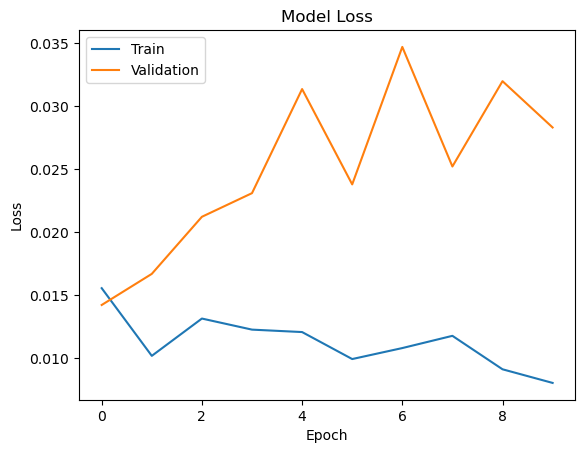

In [21]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("Model Loss")
plt.ylabel("Loss")
plt.xlabel("Epoch")

plt.legend(['Train','Validation'])
plt.savefig("model-loss.png")

plt.show()

## Key Learnings
• Learned TensorFlow and Keras basics.  
• Built a multi-layer neural network.  
• Understood hyperparameter tuning.  
• Learned to detect overfitting.  
• Applied Dropout regularization.  
• Visualized training and validation metrics.  